<a href="https://colab.research.google.com/github/TinyZhen/cs666student/blob/main/CS666_Assignment_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

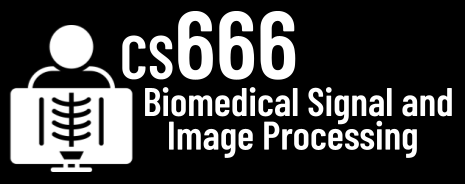

# Assignment 1

In [1]:
%pylab inline

Populating the interactive namespace from numpy and matplotlib


**Task 1** (5 pts): Install the BioSPPY library with the following code.

In [2]:
!pip install biosppy
!pip install peakutils

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 159.5/159.5 kB 4.1 MB/s eta 0:00:00


**Task 2** (10 pts): Download a sample ecg dataset from https://cs666.org/data/ecg.txt and upload it to this colab. The following code loads the dataset. Note: this might fail with an import error, but should be an easy fix :)

In [3]:
!wget https://cs666.org/data/ecg.txt

--2026-02-18 02:05:51--  https://cs666.org/data/ecg.txt
Resolving cs666.org (cs666.org)... 185.199.110.153, 185.199.111.153, 185.199.108.153, ...
Connecting to cs666.org (cs666.org)|185.199.110.153|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 105085 (103K) [text/plain]
Saving to: ‘ecg.txt’

ecg.txt             100%[===================>] 102.62K  --.-KB/s    in 0.02s   

2026-02-18 02:05:51 (6.59 MB/s) - ‘ecg.txt’ saved [105085/105085]



In [43]:
from biosppy import storage
signal, metadata = storage.load_txt('ecg.txt')

**Task 3** (10 pts): Figure out the sampling rate for this data and how many seconds it lasts.

In [5]:
len(signal)


15000

In [6]:
SAMPLING_RATE = 1000
SECONDS = 15

**Task 4** (15 pts): Process the signal with BioSPPY using the `ecg.ecg` method.

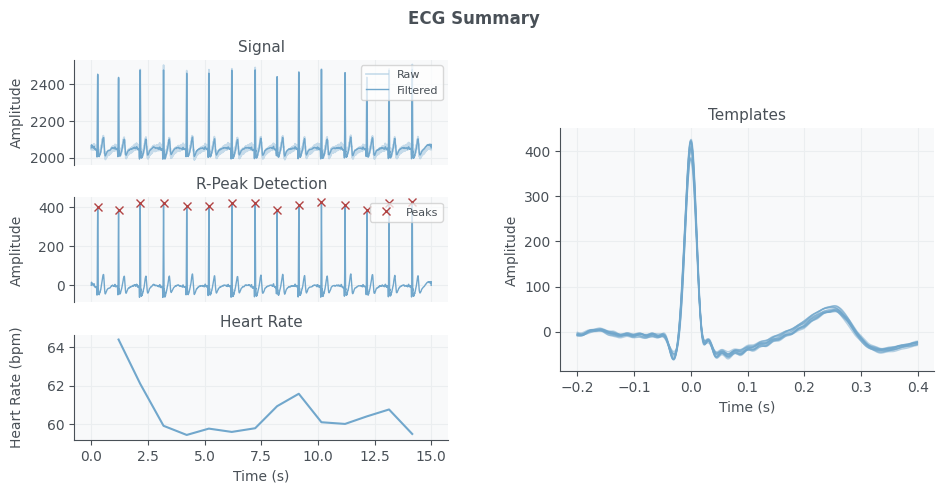

In [7]:
import biosppy
out = biosppy.signals.ecg.ecg(signal=signal, sampling_rate=SAMPLING_RATE, units=None, path=None, show=True, interactive=False)

**Task 5** (10 pts): Plot the first 3 seconds of the unfiltered signal and then the filtered signal. Can you spot the P, Q, R, S, T waves?

Text(0, 0.5, 'Amplitude')

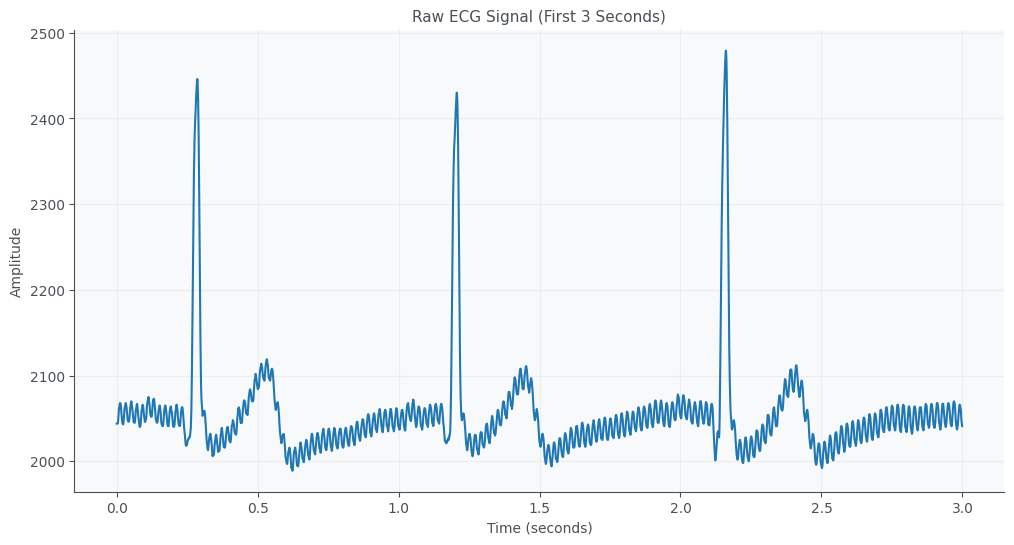

In [23]:

import numpy as np
import matplotlib.pyplot as plt
first_3s = signal[:3 * SAMPLING_RATE]

t = np.arange(len(first_3s)) / SAMPLING_RATE


plt.figure(figsize=(12,6))


plt.plot(t, first_3s)
plt.title("Raw ECG Signal (First 3 Seconds)")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")

In the filtered ECG Signal, P,Q,R,S,T waves can be easily spotted! R can be easily spotted as it is the tallest peak in the graph, The Q and S waves are small negative deflections around the R-peak. The P-wave appears as a small positive deflection preceding each R-peak. and T appears as a broader positive wave following the R-Peak. 


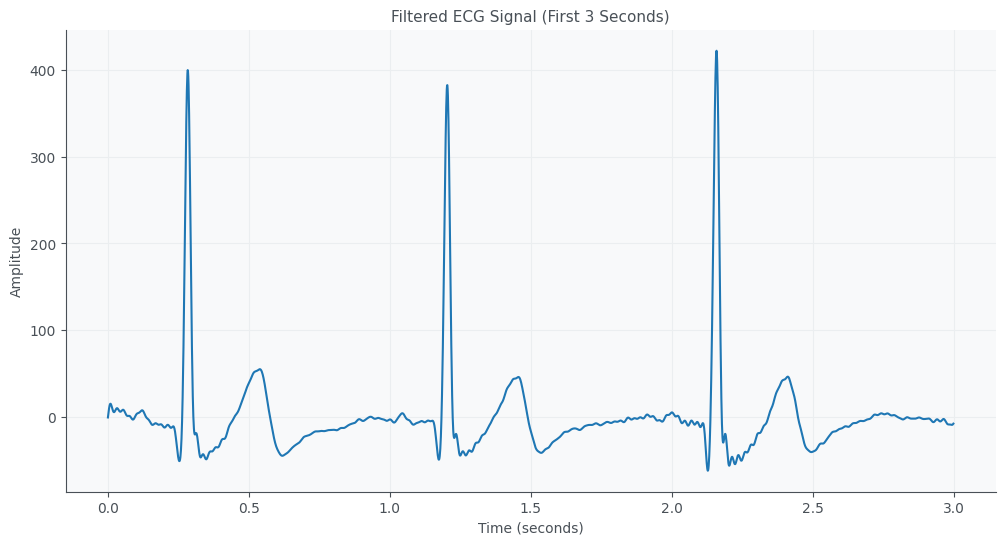

In [24]:
filtered = out['filtered'][:3 * SAMPLING_RATE]
plt.figure(figsize=(12,6))

plt.plot(t, filtered)
plt.title("Filtered ECG Signal (First 3 Seconds)")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")

print("In the filtered ECG Signal, P,Q,R,S,T waves can be easily spotted! R can be easily spotted as it is the tallest peak in the graph, The Q and S waves are small negative deflections around the R-peak. The P-wave appears as a small positive deflection preceding each R-peak. and T appears as a broader positive wave following the R-Peak. ")

**Task 6** (15 pts): Please plot the whole filtered signal and mark the r-peaks with vertical lines based on the ecg.ecg output. You can use `plt.axvline(x = 100, color = 'r', ls=':')` to create a red, dashed vertical line at position 100. Please label the x-axis as 'time [s]'.

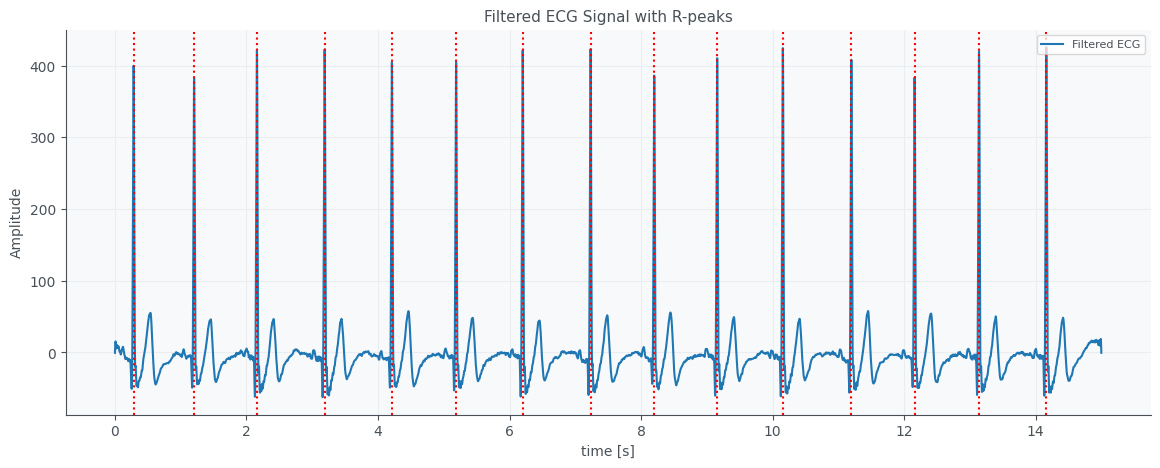

In [33]:
filtered = out['filtered']
rpeaks = out['rpeaks']

t = np.arange(len(filtered)) / SAMPLING_RATE

plt.figure(figsize=(14,5))
plt.plot(t, filtered, label="Filtered ECG")

for r in rpeaks:
    plt.axvline(x=r/SAMPLING_RATE, color='r', ls=':')

plt.xlabel("time [s]")
plt.ylabel("Amplitude")
plt.title("Filtered ECG Signal with R-peaks")
plt.legend()
plt.show()

**Task 7** (5 pts): Let's install the NeuroKit2 library.

In [29]:
!pip install neurokit2
import neurokit2 as nk

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 708.4/708.4 kB 12.0 MB/s eta 0:00:00


**Task 8** (20 pts): Detect P Q S T Peaks using Neurokit.

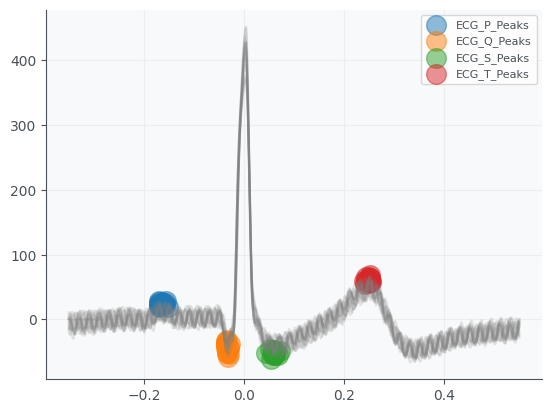

In [45]:
# We know the R spikes now but what about P Q S T waves?
signal_centered = signal - np.mean(signal)
_, waves_peak = nk.ecg_delineate(signal_centered,
                                 rpeaks,
                                 sampling_rate=SAMPLING_RATE,
                                 method="peak",
                                 show=True,
                                 show_type='peaks')
# TODO Can you use nk.ecg_delineate to detect them in the unfiltred signal?
# Hint: Look at the tutorial: https://neuropsychology.github.io/NeuroKit/examples/ecg_delineate/ecg_delineate.html
# Hint 2: The plot will have blue, orange, green, and red circles :)
# Hint 3: rpeaks were detected above from biosppy's ecg.ecg method

In [46]:
# TODO Does the detection work well?
print("The library successfully detects the correct waves")

The library successfully detects the correct waves


**Task 9** (10 pts): Use the sleepecg library to find the R Peaks.

In [48]:
# We have the R spikes/peaks now from Biosppy from above but there is another
# library called sleepecg.
# TODO Please install it and run the rpeak detection!
!pip install sleepecg
from sleepecg import detect_heartbeats
beats = detect_heartbeats(signal, SAMPLING_RATE)

# Docs: https://sleepecg.readthedocs.io/en/stable/

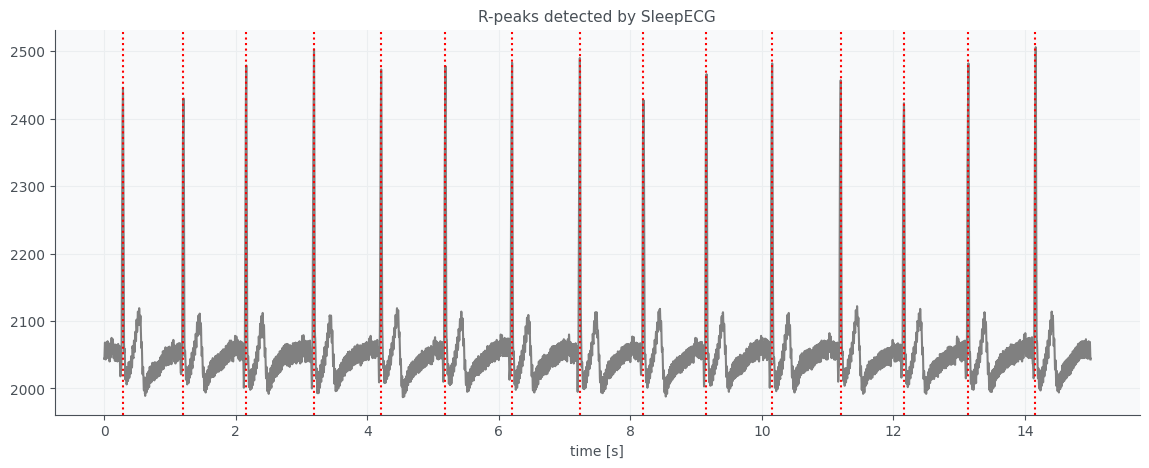

In [50]:
t = np.arange(len(signal)) / SAMPLING_RATE

plt.figure(figsize=(14,5))
plt.plot(t, signal, color='gray')

for r in beats:
    plt.axvline(x=r/SAMPLING_RATE, color='red', linestyle=':')

plt.xlabel("time [s]")
plt.title("R-peaks detected by SleepECG")
plt.show()

In [54]:
len(rpeaks_sleep)

15

In [55]:
# TODO Do Biosppy and sleepecg give different rpeaks? Please calculate the MSE!
rpeaks_bio = out['rpeaks']

# rpeaks from sleepecg
rpeaks_sleep = beats

r1 = rpeaks_bio[:15]
r2 = rpeaks_sleep[:15]

mse = np.mean((r1 - r2)**2)

print("MSE between BioSPPY and SleepECG R-peaks:", mse)

MSE between BioSPPY and SleepECG R-peaks: 0.2


**Bonus Task** (33 pts): Detect P Q S T Peaks for the full signal before and after filtering.

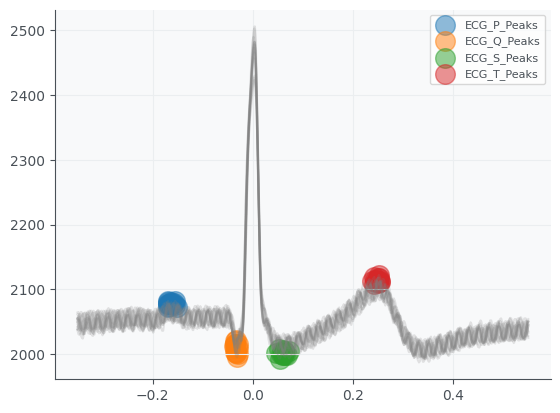

In [56]:
# TODO As above use the nk.ecg_delineate function to detect peaks for the whole signal
signals, info = nk.ecg_process(signal, sampling_rate=SAMPLING_RATE)

rpeaks = info["ECG_R_Peaks"]
signals_delineate, waves_peak = nk.ecg_delineate(
    signal,
    rpeaks,
    sampling_rate=SAMPLING_RATE,
    method="peak",
    show=True,
    show_type="peaks"
)

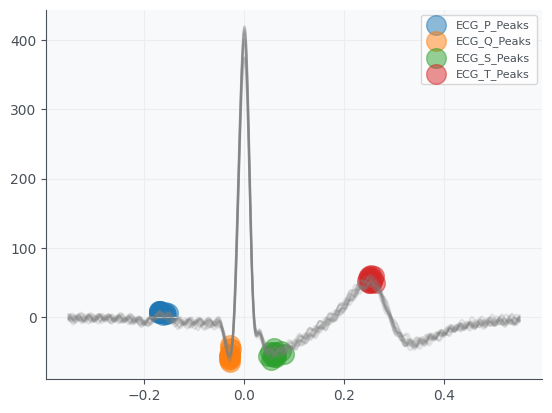

In [65]:
# TODO Let's filter the signal and see if the detection improves.
# Hint: You can use nk.signal_filter to define a bandpass.
# Hint 2: Which lowcut and highcut frequencies work well? Play with it :)
# Hint 3: You don't need to re-calculate the rpeaks since they are pretty accurate in general.

signal_filtered = nk.signal_filter(
    signal,
    sampling_rate=SAMPLING_RATE,
    lowcut=1,
    highcut=45,
    method="butterworth",
    order=4
)

_, waves_peak = nk.ecg_delineate(
    signal_filtered,
    rpeaks,
    sampling_rate=SAMPLING_RATE,
    method="peak",
    show=True,
    show_type="peaks"
)

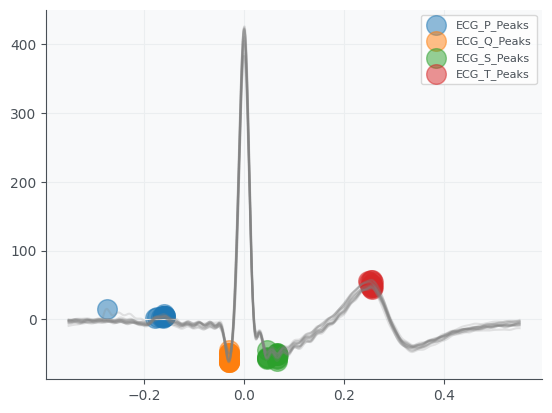

In [66]:
# Finally, run the delineation on the filtered signal from BioSPPY.
filtered_bio = out['filtered']
rpeaks = out['rpeaks']

_, waves_peak = nk.ecg_delineate(
    filtered_bio,
    rpeaks,
    sampling_rate=SAMPLING_RATE,
    method="peak",
    show=True,
    show_type="peaks"
)

In [67]:
# TODO Which one works the best?
print("When I apply a bandpass filter, the detected peak markers (the circles) appear more concentrated and consistent. However, when I use the BioSPPY filtered signal, the detected peaks look more scattered or dispersed.")

When I apply a bandpass filter, the detected peak markers (the circles) appear more concentrated and consistent. However, when I use the BioSPPY filtered signal, the detected peaks look more scattered or dispersed.


In [ ]:
#
# Great job!!
#
#  , ; ,   .-'"""'-.   , ; ,
#  \\|/  .'         '.  \|//
#   \-;-/   ()   ()   \-;-/
#   // ;               ; \\
#  //__; :.         .; ;__\\
# `-----\'.'-.....-'.'/-----'
#        '.'.-.-,_.'.'
#jgs       '(  (..-'
#            '-'
#